In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
import random
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import numpy as np, pandas as pd
from tqdm import tqdm


In [4]:
# Custom functions for alpha calculations
import importlib.util
import sys
from WorldQuant_alpha101_code.alphas import *
from WorldQuant_alpha101_code.test_alphas import *

#### Part 0: Obtaining stock data

In [5]:
tickers = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV']
industries = {'XLB': 'Buildings',
             'XLE': 'Energy',
             'XLF': 'Financials',
             'XLI': 'Industrials',
             'XLK': 'Technology',
             'XLP': 'Consumer Staples',
             'XLU': 'Utilities',
             'XLV': 'Healthcare'
             }
start_date = dt.datetime(2000,1,1)
end_date = dt.datetime(2025,10,1)

stock_data = yf.download(tickers, start_date, end_date,auto_adjust=False)
tickers = stock_data['Close'].columns.tolist()

[*********************100%***********************]  8 of 8 completed


In [6]:
stock_data = stock_data.drop(columns=['Close']).rename(columns={'Adj Close':'Close'})

In [7]:
# Calculate returns for each ticker separately
returns = stock_data['Close'].pct_change()

# Add as new top-level column
for ticker in stock_data['Close'].columns:
    stock_data[('Returns', ticker)] = returns[ticker]

In [8]:
# nav_dict = {}
# for ticker in tickers:
#     df = pd.read_excel(f'ETF data/navhist-us-en-{ticker.lower()}.xlsx',
#                                      skiprows=3)
#     df = df[['Date','Shares Outstanding']]
#     df = df[~(df['Shares Outstanding'].isnull()) & ~(df['Shares Outstanding']=='-')]
#     df['Date'] = pd.to_datetime(df['Date'])
#     df['Shares Outstanding'] = df['Shares Outstanding'].astype(float)
#     df = df.set_index('Date')

#     nav_dict[ticker] = df.sort_index(ascending=True).copy()

In [9]:
# # nav_dict['XLP'][nav_dict['XLP'].columns[3]]
# df = nav_dict['XLP']

# df

In [10]:
# for ticker, df in nav_dict.items():
#     stock_data[('Shares Outstanding', ticker)] = df['Shares Outstanding']
    

In [11]:
# stock_data['Close']

In [12]:
# for ticker in tickers:
#     stock_data[('Market_Cap', ticker)] = stock_data[('Close', ticker)] * stock_data[('Shares Outstanding', ticker)]
# stock_data = stock_data.dropna(subset=[('Market_Cap', ticker) for ticker in tickers], how='all')

In [13]:
pd.MultiIndex.from_tuples([(col[0], col[1]) for col in stock_data.columns])

MultiIndex([(  'Close', 'XLB'),
            (  'Close', 'XLE'),
            (  'Close', 'XLF'),
            (  'Close', 'XLI'),
            (  'Close', 'XLK'),
            (  'Close', 'XLP'),
            (  'Close', 'XLU'),
            (  'Close', 'XLV'),
            (   'High', 'XLB'),
            (   'High', 'XLE'),
            (   'High', 'XLF'),
            (   'High', 'XLI'),
            (   'High', 'XLK'),
            (   'High', 'XLP'),
            (   'High', 'XLU'),
            (   'High', 'XLV'),
            (    'Low', 'XLB'),
            (    'Low', 'XLE'),
            (    'Low', 'XLF'),
            (    'Low', 'XLI'),
            (    'Low', 'XLK'),
            (    'Low', 'XLP'),
            (    'Low', 'XLU'),
            (    'Low', 'XLV'),
            (   'Open', 'XLB'),
            (   'Open', 'XLE'),
            (   'Open', 'XLF'),
            (   'Open', 'XLI'),
            (   'Open', 'XLK'),
            (   'Open', 'XLP'),
            (   'Open', 'XLU'),
        

#### Part 1: Factor construction

Start with raw stock data. Compute 82 of 101 alphas

- Core Alpha101-style technical factors

In [ ]:
# Alphas = Alphas(stock_data)

# Dealing with NaNs in Alphas
## Source of NaNs
a. Rolling window
    - these occur when there is a rolling window that results in NaNs at the start of the alpha created

b. Systematic NaNs
    - these occur due to systematic computation of the formula that results in NaNs happening sporadically. 
    - Need to further investigate these

In [ ]:
# # List all alpha methods in the Alphas class
# alpha_methods = \
# [method for method in dir(Alphas) 
#             if method.startswith('alpha') and method[5:].isdigit()]

In [ ]:
# # factor application function
# def build_factor_table(stock_data, alpha_methods, alphas_instance, industry_map, gap=1, horizon=21):
#     """Build a long-format factor table.

#     Compute specified alpha series, concatenate into a long DataFrame (date, ticker),
#     attach market capitalization and industry, and compute forward returns
#     using `gap` and `horizon`.

#     Inputs:
#         stock_data (pd.DataFrame): price/metrics panel with MultiIndex columns
#             like ('Close', ticker) and ('Market_Cap', ticker).
#         alpha_methods (iterable[str]): names of alpha methods to call on
#             alphas_instance (e.g. ['alpha001', 'alpha050']).
#         alphas_instance (object): instance or class exposing alpha methods that
#             return DataFrame (dates x tickers).
#         industry_map (dict): mapping {ticker: industry_name}.
#         gap (int): days to skip before the forward-return window (default 1).
#         horizon (int): forward-return window length in days (default 21).

#     Returns:
#         pd.DataFrame: index (date, ticker) with alpha columns, 'market_cap', 'industry', 'forward_return'.
#     """
#     CLIPPING_VALUE = 1e6
#     #  ---------- Step 1: Get Alphas ----------
#     factors = []

#     print(f"Calculating Alphas...")
#     for method_name in tqdm(alpha_methods):
#         try:
#             alpha_func = getattr(alphas_instance, method_name)
#             alpha_df = alpha_func()

#             # Clip to avoid exploding values
#             alpha_df = alpha_df.clip(lower=-CLIPPING_VALUE, upper=CLIPPING_VALUE)
#             alpha_df = alpha_df.replace([np.inf, -np.inf], np.nan).fillna(0)

#             # Flatten MultiIndex (date, stock) into Series
#             alpha_series = alpha_df.stack().rename(method_name)
#             factors.append(alpha_series)

#         except Exception as e:
#             print(f"❌ {method_name} failed: {e}")
#     print(f"Alphas done.")
#     # Combine all alpha factors into one DataFrame
#     factors_df = pd.concat(factors, axis=1)

#     print(f"Final factors_df shape: {factors_df.shape}")

#     # ---------- Step 2: Add Market Cap and Industry ----------
#     factors_df['market_cap'] = stock_data['Market_Cap'].stack()
#     factors_df['industry'] = factors_df.index.get_level_values('Ticker').map(industry_map)

#     # ---------- Step 3: Compute forward returns ----------
#     factors_df['forward_return'] = (stock_data['Close'].shift(-(gap + horizon - 1)) / 
#                                             stock_data['Close'].shift(-gap) - 1).stack()

#     # ---------- Step 4: Keep only indexes that are available for all these ----------
#     factors_df = factors_df.dropna(how="any", subset=alpha_methods + ['market_cap', 'forward_return'])
    
#     factors_df = factors_df.sort_index()

#     return factors_df
    

In [ ]:
# factor_table = build_factor_table(stock_data, alpha_methods, Alphas, industries)

Calculating Alphas...


 76%|███████▌  | 62/82 [00:32<00:10,  1.94it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
100%|██████████| 82/82 [01:15<00:00,  1.09it/s]


Alphas done.
Final factors_df shape: (38920, 82)


Notes:
- Market capitalisation is included in the data pipeline even though it itself is not an alpha factor. Market cap represents firm size, which is one of the strongest systematic risk factors in asset pricing.
- If size is not controlled for, many factors will simply be disguised size effects (e.g. if momentum or liquidity factor loads heavily on small caps, it looks predictive, but the model would simply be leaning into the size bias - small caps having higher vol, higher momentum and lower liquidity).
- The eventual size neutralization in the pipeline is: Regressing each factor on log(MarketCap) and (log(MarketCap))<sup>2</sup> per date, then using residuals as the pure alpha.

# Measure baseline IC
## Function to compute information coefficient


In [ ]:
def compute_ic(table, factor_col_neut, forward_return_col='forward_return'):
    """
    
    """
    # compute pearson (or spearman) cross-sectional correlation per date between factor and forward return
    dates = table['Date'].unique()
    ic_series = []
    for dt in dates:
        s = table[table['Date']==dt]
        if s.shape[0] < 5:
            ic_series.append(np.nan)
            continue
        a = s[factor_col_neut].values
        b = s[forward_return_col].values
        # use spearman or pearson
        try:
            rho = np.corrcoef(a, b)[0,1]
        except Exception:
            rho = np.nan
        ic_series.append(rho)
    return pd.Series(ic_series, index=dates)

In [ ]:
ic_list = [compute_ic(factor_table.reset_index(), col) for col in alpha_methods]
ic_df = pd.concat(ic_list, axis=1)
ic_df.isnull().sum().sort_values().tail(10)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.12/lib/pytho

59     784
45     785
6      786
58     861
56     934
20    1048
77    4842
73    4844
26    4844
61    4844
dtype: int64

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

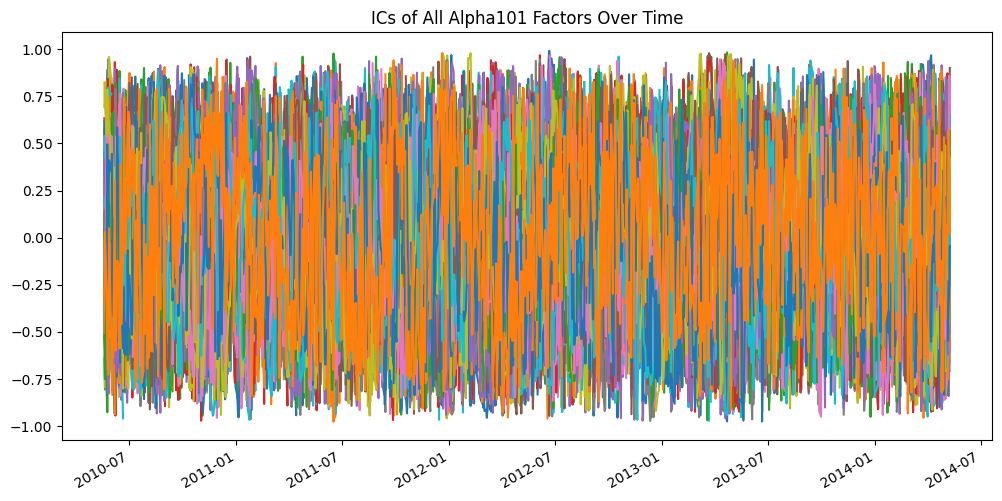

In [ ]:
ic_df.iloc[1000:2000].plot(legend=False, figsize=(12,6), title='ICs of All Alpha101 Factors Over Time')

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

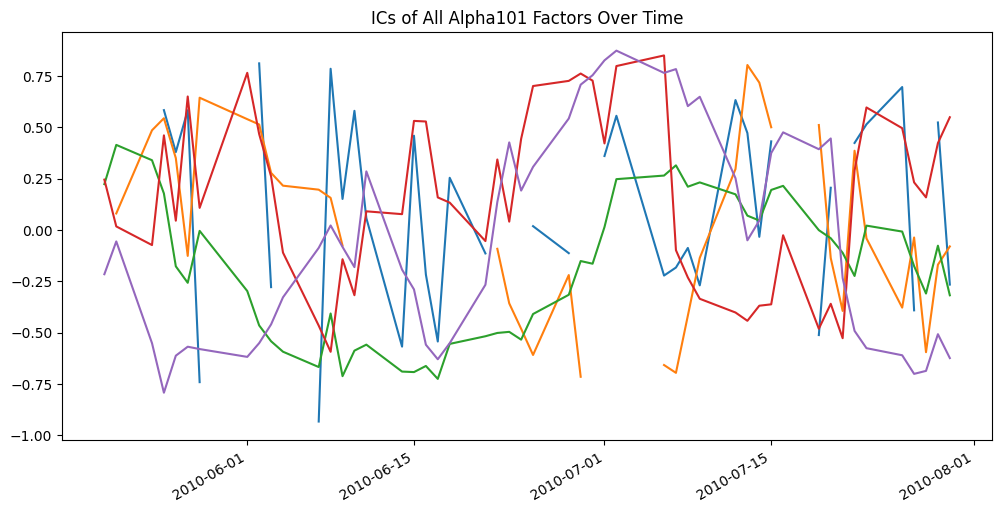

In [ ]:
ic_df.iloc[1000:1050][ic_df.columns[random.sample(range(ic_df.shape[1]),5)]]\
    .plot(legend=False, 
          figsize=(12,6), 
          title='ICs of All Alpha101 Factors Over Time')

#### Part 3: Bias correction / neutralisation

Raw factors are not pure predictors, they often capture structural biases like:

- Industry effects (tech stocks move together)

- Size effects (small caps have higher volatility)

- Market-wide trends (momentum correlates with beta)

Neutralization ensures your factor’s correlation with forward returns isn’t just due to those broad effects.

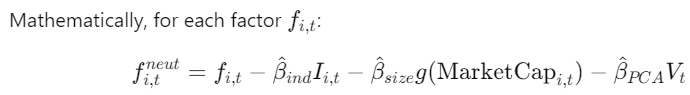

Stage 1. Identify systematic risk factors (via PCA)

Compute correlation matrix of factors.

Extract top K eigenvectors (principal components) representing “market-wide” common movements.

Optional: project factors orthogonally to remove those common components:
​
![image.png](attachment:ed279968-c4f5-4c21-b302-50b718d4710c.png)

Stage 2: Industry neutralisation

Regress each factor cross-sectionally on industry dummy variables:

![image.png](attachment:dde99fde-80d3-420e-8ff6-a12678a4b7fc.png)

Use robust regression (e.g., Huber, ridge) to avoid outlier distortion.

Stage 3: Size neutralisation (market cap bias)

Fit a log-linear model to remove linear and quadratic size effects

Stage 4: Adaptive neutralisation strength

In high-volatility regimes, use stronger neutralization (Du eq. 8):

![image.png](attachment:cc901f04-7497-40fb-9ca0-2b356a48c1cb.png)

Stage 5: Standardisation

After all neutralisation: Cross-sectionally z-score each factor (mean 0, std 1 per day).
This ensures no factor dominates due to scale.

In [ ]:
# Neutralisation function
def neutralize_cross_sectional(table, factor_cols, industry_col='industry', cap_col='market_cap', variance_threshold=0.95, ridge_alpha=1.0):
    """
    table: long-format df with columns ['date','ticker', factor_cols..., industry_col, cap_col]
    factor_cols: list of factor column names to neutralize
    variance_threshold: the amount of variance to explain via PCA, e.g., 0.95 means 95% variance
    steps:
      1) for each date, create cross-sectional matrix F (n_stocks x n_factors)
      2) optional: PCA decomposition on F (correlation or covariance) and remove projection onto components that explain the desired variance threshold
      3) industry neutralization: regress each factor on industry dummies (ridge) and subtract predicted
      4) size neutralization: regress residual on log(market_cap) and (log(market_cap))^2
      5) z-score each factor cross-sectionally (per date)
    returns: table with neutralized factor columns appended as e.g. mom12_neut
    """
    out_rows = []
    dates = table['Date'].unique()
    
    for dt in tqdm(dates, desc='Neutralizing per date'):
        slice_df = table[table['Date'] == dt].copy()
        # TODO WHY DO WE NEED TO SKIP IF ITS LESS THAN 10
        # if slice_df.shape[0] < 10:
        #     # too few names - skip neutralization but still zscore
        #     for f in factor_cols:
        #         slice_df[f + '_neut'] = zscore(slice_df[f].fillna(0).values)
        #     out_rows.append(slice_df)
        #     continue
        

        # Build factor matrix F (n_stocks x n_factors)
        F = slice_df[factor_cols].values
        
        # --- PCA removal based on variance threshold
        if variance_threshold is not None and variance_threshold > 0:
            # Standardize the factors (columns mean=0, variance=1)
            scaler = StandardScaler(with_mean=True, with_std=True)
            Fc = scaler.fit_transform(F)
            
            # Perform PCA and get explained variance ratio
            pca = PCA()
            pca.fit(Fc)
            explained_variance_ratio = pca.explained_variance_ratio_

            # Find the number of components that explain at least `variance_threshold` amount of variance
            cumulative_variance = np.cumsum(explained_variance_ratio)
            # n_pcs_remove = np.argmax(cumulative_variance >= variance_threshold) + 1  # Get the number of PCs required
            n_pcs_remove = 1 
            
            # If no components are required to meet the threshold, skip PCA
            # if n_pcs_remove > 0:
            #     pcs = pca.transform(Fc)  # Project data onto the principal components
            #     reconstructed = pca.inverse_transform(pcs[:, :n_pcs_remove])  # Reconstruct the part to remove
            #     F = Fc - reconstructed
            # else:
            #     # If n_pcs_remove is 0, we leave the data unchanged
            #     F = Fc
            # TODO replace above with this to solve the dimension issue
            if n_pcs_remove > 0:
                pcs = pca.transform(Fc)  # Project data onto the principal components
                # Zero out the first n_pcs_remove components
                pcs_filtered = pcs.copy()
                pcs_filtered[:, :n_pcs_remove] = 0
                # Reconstruct using the remaining components
                F = pca.inverse_transform(pcs_filtered)
            else:
                F = Fc

        # Build industry dummies
        industries = pd.get_dummies(slice_df[industry_col].fillna('UNK'))
        
        # Regress each factor on industry dummies (ridge regression)
        X_ind = industries.values
        X_size = np.column_stack([np.log(slice_df[cap_col].values + 1e-9), np.log(slice_df[cap_col].values + 1e-9)**2])
        
        # Industry regression (Ridge to regularize)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=True)
        F_ind_neut = np.zeros_like(F)
        for j in range(F.shape[1]):
            y = F[:, j]
            # print(X_ind, y)
            ridge.fit(X_ind, y)
            y_hat = ridge.predict(X_ind)
            resid = y - y_hat
            F_ind_neut[:, j] = resid

        # Size neutralization: regress residual on log(cap) and squared
        F_size_neut = np.zeros_like(F_ind_neut)
        ridge2 = Ridge(alpha=ridge_alpha, fit_intercept=True)
        for j in range(F_ind_neut.shape[1]):
            y = F_ind_neut[:, j]
            # print(dt)
            # print(X_size)
            ridge2.fit(X_size, y)
            y_hat = ridge2.predict(X_size)
            resid = y - y_hat
            F_size_neut[:, j] = resid

        # Now z-score each column cross-sectionally
        F_z = (F_size_neut - np.nanmean(F_size_neut, axis=0)) / (np.nanstd(F_size_neut, axis=0) + 1e-9)

        # Attach results
        for idx, ticker in enumerate(slice_df['Ticker'].values):
            for j, f in enumerate(factor_cols):
                slice_df.at[slice_df.index[idx], f + '_neut'] = F_z[idx, j]
        out_rows.append(slice_df)

    out_df = pd.concat(out_rows, axis=0).sort_values(['Date','Ticker']).reset_index(drop=True)
    return out_df

In [ ]:
# factor_table[alpha_methods].isnull().sum().sum()

0

In [ ]:
# neut_df = neutralize_cross_sectional(
#     factor_table.reset_index(),
#     alpha_methods,
#     industry_col='industry',
#     cap_col='market_cap')
# neut_df

Neutralizing per date:  43%|████▎     | 2079/4844 [01:49<02:18, 19.96it/s]

In [ ]:
# neut_df.to_csv('../data/factor_table_neut_v2.csv', index=False)

In [ ]:
# idx= 33

# df = neut_df[neut_df['Date']==neut_df['Date'][2000]].copy()
# corr_before = df[alpha_methods[idx]].corr(df['market_cap'])
# corr_after = df[f'{alpha_methods[idx]}_neut'].corr(df['market_cap'])
# print(corr_before, corr_after)

-0.15479425801165134 -0.1302006027660956


the effect of neutralisation is not very strong for majority of the factors

In [ ]:
# method = random.choice(alpha_methods)

# print(f'The mean of {method} is {neut_df[method].mean()}. It should be close to 0')
# print(f'The std of {method} is {neut_df[method].std()}. It should be close to 1')

# per_date_corrs = neut_df.groupby('Date').apply(
#     lambda df: df[method].corr(df['market_cap'])
# )
# print(per_date_corrs.mean())

The mean of alpha088 is 0.498220348458758. It should be close to 0
The std of alpha088 is 0.288282010212564. It should be close to 1
0.11220142063664945

/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_15590/1644060755.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_date_corrs = neut_df.groupby('Date').apply(


In [ ]:
# re-compute ICs for neutralized factors
# neut_alpha_methods = [f + '_neut' for f in alpha_methods]

# ic_list = [compute_ic(neut_df, col) for col in neut_alpha_methods]
# ic_df = pd.concat(ic_list, axis=1)
# ic_df.isnull().sum().sort_values().tail(10)

/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


59     784
45     785
6      786
58     861
56     934
20    1048
77    4842
73    4844
26    4844
61    4844
dtype: int64

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

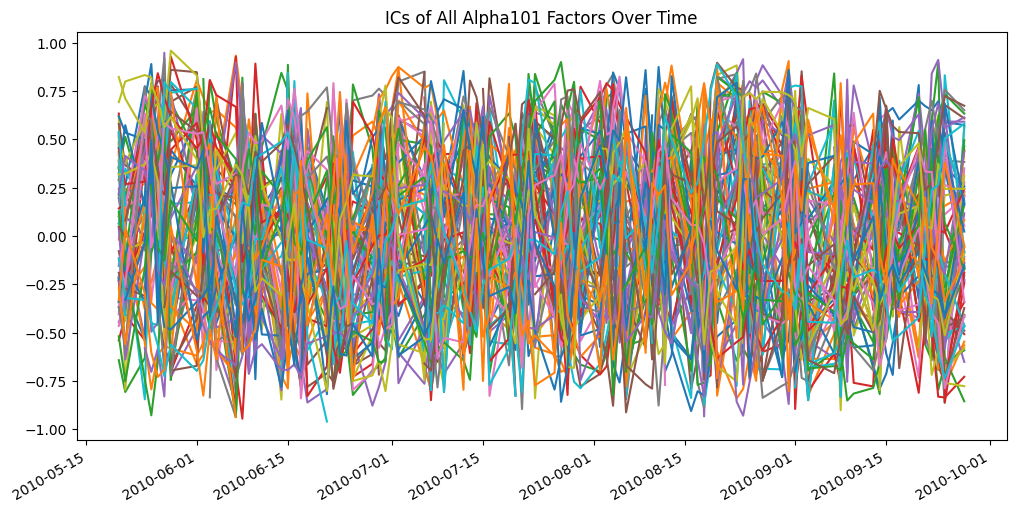

In [ ]:
# ic_df.iloc[1000:1090].plot(legend=False, figsize=(12,6), title='ICs of All Alpha101 Factors Over Time')

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

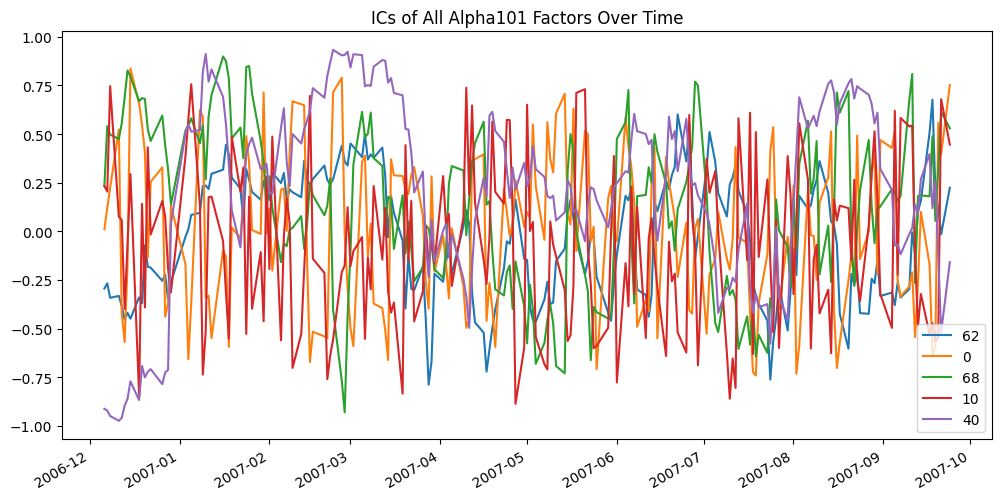

In [ ]:
# window = 200
# start = random.randint(0, len(ic_df) - window)
# sampled_rows = ic_df.iloc[start:start + window]
# sampled_cols = random.sample(list(ic_df.columns), 5)

# sampled_rows[sampled_cols].sort_index().plot(
#     legend=True,
#     figsize=(12, 6),
#     title='ICs of All Alpha101 Factors Over Time'
# )

Each IC series is a time series of daily correlations between the neutralized factor values and the forward returns over the 21-day horizon. It is a measure of, on each day, how well the factor's ranking predicted the cross-sectional return ranking over the next period 

Interpretation of mean ICs

| Mean IC    | Typical interpretation                  |
| ---------- | --------------------------------------- |
| > 0.05     | Very strong factor (rare)               |
| 0.02–0.05  | Good, likely tradable                   |
| 0.005–0.02 | Weak but possibly useful in combination |
| ~0         | Noise / no predictive power             |
| < 0        | Inverted signal (could short it)        |


In [ ]:
# def compute_ic_summary(ic_df):
#     ic_summary = []
#     for series in ic_df.columns:
#         ic_summary.append({
#             'Factor': series,
#             'Mean IC': ic_df[series].mean(),
#             'Std IC': ic_df[series].std(),
#             'Information ratio': ic_df[series].mean() / ic_df[series].std(),
#             'Hit ratio': (ic_df[series] > 0).mean(),
#             'Miss ratio': (ic_df[series] < 0).mean()
#         })
#     return pd.DataFrame(ic_summary)

# ICs_summary = compute_ic_summary(ic_df)
# display(ICs_summary)

,Factor,Mean IC,Std IC,Information ratio,Hit ratio,Miss ratio
0,0,-0.003271,0.414145,-0.007899,0.497729,0.498348
1,1,0.003910,0.404642,0.009663,0.509290,0.486581
2,2,-0.008848,0.406518,-0.021767,0.486168,0.511974
3,3,0.001367,0.447705,0.003053,0.488233,0.475434
4,4,0.006501,0.425345,0.015285,0.503303,0.494633
...,...,...,...,...,...,...
77,77,-0.277782,0.287899,-0.964859,0.000000,0.000413
78,78,0.008317,0.385933,0.021550,0.487614,0.476879
79,79,-0.020537,0.412727,-0.049759,0.483485,0.516515
80,80,-0.000591,0.394504,-0.001499,0.449422,0.445293


In [ ]:
# # Selection of top factors
# # ICs_summary.sort_values(by='Mean IC', ascending=False).head(20)
# ICs_summary.sort_values(by='Mean IC', ascending=False).tail(20)

,Factor,Mean IC,Std IC,Information ratio,Hit ratio,Miss ratio
58,58,-0.015741,0.417622,-0.037691,0.395747,0.426507
5,5,-0.015781,0.406914,-0.038783,0.478737,0.519405
17,17,-0.016175,0.427896,-0.037801,0.474195,0.521883
52,52,-0.017095,0.430183,-0.039740,0.420520,0.455615
63,63,-0.019435,0.397537,-0.048890,0.476466,0.523534
79,79,-0.020537,0.412727,-0.049759,0.483485,0.516515
32,32,-0.025161,0.426007,-0.059062,0.476879,0.522709
72,72,-0.025739,0.395016,-0.065159,0.470479,0.521883
46,46,-0.027652,0.418372,-0.066094,0.467795,0.528282
36,36,-0.028008,0.391969,-0.071455,0.455615,0.500000


# Pruning Factors

A multi-factor strategy’s goal isn’t just maximizing each factor’s standalone IC.

It’s about combining diverse, weakly correlated signals so the aggregate IC (or portfolio IR) is more stable.

*Key points:*

- Low correlation / orthogonal ICs → smoother combined performance.
- Factor rotation or pattern recognition (e.g., regime detection via ML or macro states) helps allocate weight dynamically.
- A few moderate-IC but complementary factors can outperform one large-IC factor that decays quickly.
- Think “ensemble learning” — robustness through diversification, not dominance.


> So yes, non-overlapping, compensating IC patterns across factors are often more valuable than one big IC

will remove correlated factors

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# corr = ic_df.corr()
# # corr = corr[abs(corr) < 0.1]

# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, annot=False, fmt=".2f", cmap="coolwarm", center=0)
# plt.title("Factor Correlation Heatmap")
# plt.show()

In [ ]:
# def prune_redundant_factors(ic_df, corr_threshold=0.8):
#     """
#     Remove redundant factors that are highly correlated.
#     Keeps the one with higher mean IC when |corr| > threshold.

#     Parameters
#     ----------
#     ic_df : pd.DataFrame
#         DataFrame of IC values (index = dates, columns = factors)
#     corr_threshold : float
#         Correlation threshold to treat factors as redundant

#     Returns
#     -------
#     pd.DataFrame
#         Filtered IC DataFrame with redundant factors removed
#     """
#     corr = ic_df.corr()
#     mean_ic = ic_df.mean()

#     to_drop = set()
#     for i in corr.columns:
#         for j in corr.columns:
#             if i != j and abs(corr.loc[i, j]) > corr_threshold:
#                 # drop the one with smaller mean IC
#                 drop = j if mean_ic[i] >= mean_ic[j] else i
#                 to_drop.add(drop)

#     return ic_df.drop(columns=list(to_drop))


In [ ]:
# ic_df2 = prune_redundant_factors(ic_df, corr_threshold=0.5).dropna(how='all', axis=1)
# ic_df2.shape

In [ ]:
# plt.figure(figsize=(10, 8))
# sns.heatmap(ic_df2.corr(), annot=False, fmt=".2f", cmap="coolwarm", center=0)
# plt.title("Factor Correlation Heatmap")
# plt.show()

In [ ]:
# # Save pruned factors to a text file
# with open('../data/pruned_factors.txt', 'w') as f:
#     f.write('\n'.join(ic_df2.columns.to_list()))

> get pruned factors df

In [82]:
df = pd.read_csv('../data/factor_table_neut_v2.csv')
pruned_factors = []
with open('../data/pruned_factors.txt', 'r') as f:
    pruned_factors = f.read().splitlines()

In [83]:
factors_df = df[['Date', 'Ticker'] + pruned_factors]

In [84]:
factors_df.shape

(38752, 64)

# Create baseline with equal weighted for all factors

In [85]:
## might be useful to get base line

# build composite alpha function  builds a composite alpha column (the final signal) from the ICs of each factor combined with its weightage
# Weighting is meant to combine factors so that more predictive factors contribute more to the composite alpha
# The coding here uses absolute IC weighting and has parameterisation for equal weighting
def build_composite_alpha(table_neut, factor_cols, ic_summary=None, weighted=False):
    df = table_neut.copy()
    
    # Define weights
    if weighted and ic_summary is not None:
        weights = np.array([ic_summary.get(f, 0.0) for f in factor_cols])
        weights /= np.sum(np.abs(weights)) + 1e-12
    else:
        weights = np.ones(len(factor_cols)) / len(factor_cols)
    
    # Weighted combination (row-wise dot product)
    df['composite_alpha'] = df[factor_cols].fillna(0).dot(weights)
    
    # Z-score within each date
    df['composite_alpha'] = (df.groupby('Date')['composite_alpha'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9)))
    return df

In [86]:
factors_df

,Date,Ticker,alpha001_neut,alpha003_neut,alpha005_neut,alpha007_neut,alpha008_neut,alpha010_neut,alpha011_neut,alpha012_neut,...,alpha083_neut,alpha084_neut,alpha085_neut,alpha088_neut,alpha092_neut,alpha094_neut,alpha096_neut,alpha098_neut,alpha099_neut,alpha101_neut
0,2006-05-31,XLB,-1.569069e-06,4.698801e-07,9.402360e-09,1.270492e-09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.219420,0.000000,1.489500
1,2006-05-31,XLE,-1.680741e-07,-4.518444e-08,1.398577e-09,-1.997313e-10,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.159370,0.000000,0.609890
2,2006-05-31,XLF,-1.031251e-06,-8.937975e-08,-5.904246e-09,-1.214531e-09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.399010,0.000000,-0.501320
3,2006-05-31,XLI,-1.090069e-06,-5.617885e-07,-1.353187e-08,-2.200010e-09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.629090,0.000000,-0.458050
4,2006-05-31,XLK,-2.433166e-06,5.661438e-07,1.191302e-08,1.184700e-09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.291249,0.000000,0.612440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38747,2025-08-29,XLI,1.413780e+00,8.927283e-01,-3.066510e-02,-1.088094e-01,0.110666,0.216075,-0.170410,0.215719,...,-1.170648,0.015447,-0.139515,0.150415,-2.086835,-0.497915,-0.651970,-0.971919,1.378167,0.951394
38748,2025-08-29,XLK,5.749849e-01,4.517698e-01,4.186952e-01,6.887626e-01,-0.358625,1.159850,0.577387,1.159801,...,1.735991,-0.200080,-0.132045,-0.458612,0.542119,-0.578369,-1.237473,-0.151502,-0.406369,0.941267
38749,2025-08-29,XLP,2.010560e-01,-2.077759e+00,1.560893e+00,2.125340e+00,0.518811,-0.278550,1.697846,-0.281235,...,0.397337,-0.561395,-0.507428,1.686421,-0.106247,1.765482,-0.509252,-0.082360,-1.384038,0.239846
38750,2025-08-29,XLU,-2.306399e+00,-8.832454e-01,-6.601327e-02,-1.580663e-01,0.801728,-1.739637,-0.748443,-1.737893,...,-1.277016,0.037391,-0.047092,0.199472,1.158055,1.418650,1.826361,0.793844,-0.753303,-2.336920


In [87]:
baseline_df =\
build_composite_alpha(factors_df, pruned_factors, 
                      ic_summary=None,
                      weighted=False)

In [88]:
# baseline_df
baseline_df["rank"] = baseline_df.groupby("Date")["composite_alpha"].rank(method="first")
baseline_df["pct_rank"] = baseline_df.groupby("Date")["rank"].transform(lambda x: x / x.max())

# Buy if top half, Sell if bottom half
baseline_df["signal"] = (baseline_df["pct_rank"] > 0.5).astype(int) * 2 - 1
# gives 1 for buy, -1 for sell

# add forward returns
baseline_df = pd.merge(baseline_df, 
         df[['Date', 'Ticker', 'forward_return']], 
         on=['Date', 'Ticker'])
baseline_df['strategy_return'] = baseline_df['signal'] * baseline_df['forward_return']

In [89]:
baseline_df['gross_return'] = baseline_df['strategy_return'] +1

strategy_returns = baseline_df.groupby(["Date", "Ticker"])["gross_return"].mean()

<Axes: title={'center': 'Baseline Strategy Daily Returns Over Time'}, xlabel='Date,Ticker'>

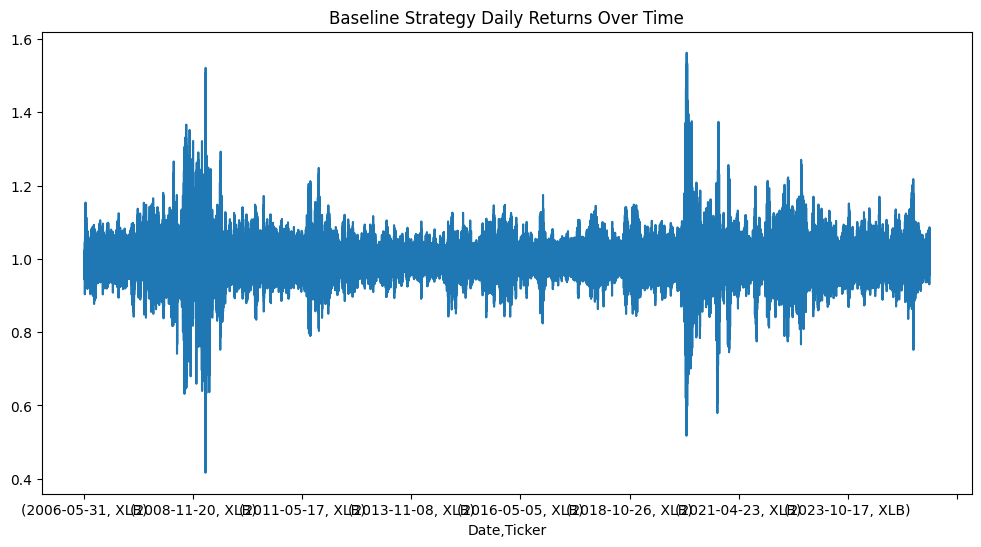

In [90]:
strategy_returns.plot(figsize=(12,6), title='Baseline Strategy Daily Returns Over Time')

<Axes: title={'center': 'Baseline Strategy Cumulative Returns Over Time'}, xlabel='Date,Ticker'>

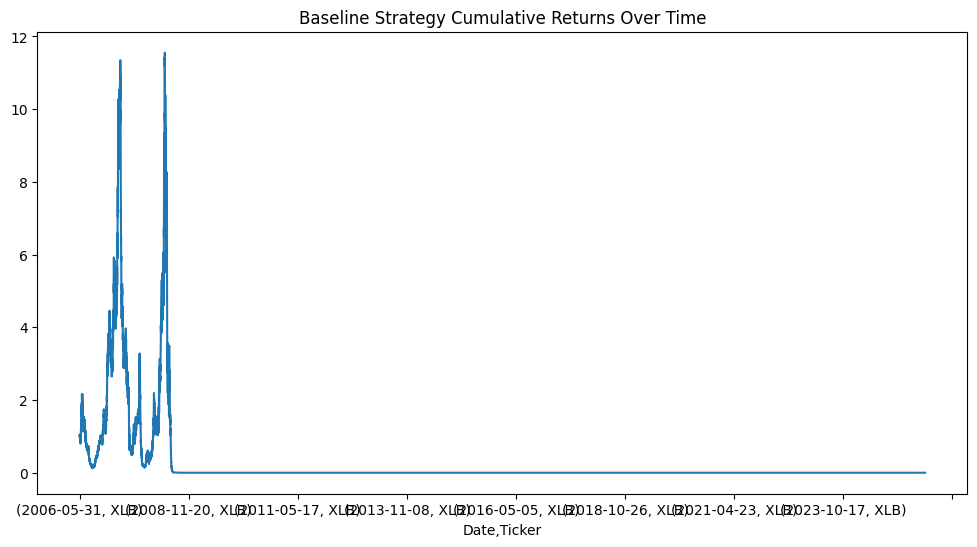

In [91]:
cum_strategy_returns = strategy_returns.cumprod()
cum_strategy_returns.plot(figsize=(12,6), title='Baseline Strategy Cumulative Returns Over Time')

In [92]:
df['forward_return'] # fwd returns is in df

0       -0.010310
1        0.019197
2       -0.013328
3       -0.011187
4       -0.016362
           ...   
38747    0.028608
38748    0.086306
38749   -0.021602
38750    0.044705
38751    0.016331
Name: forward_return, Length: 38752, dtype: float64

## Long only

In [93]:
baseline_df['passive_gross_return'] = baseline_df['forward_return'] + 1

<Axes: title={'center': 'Baseline Strategy Cumulative Returns Over Time'}, xlabel='Date'>

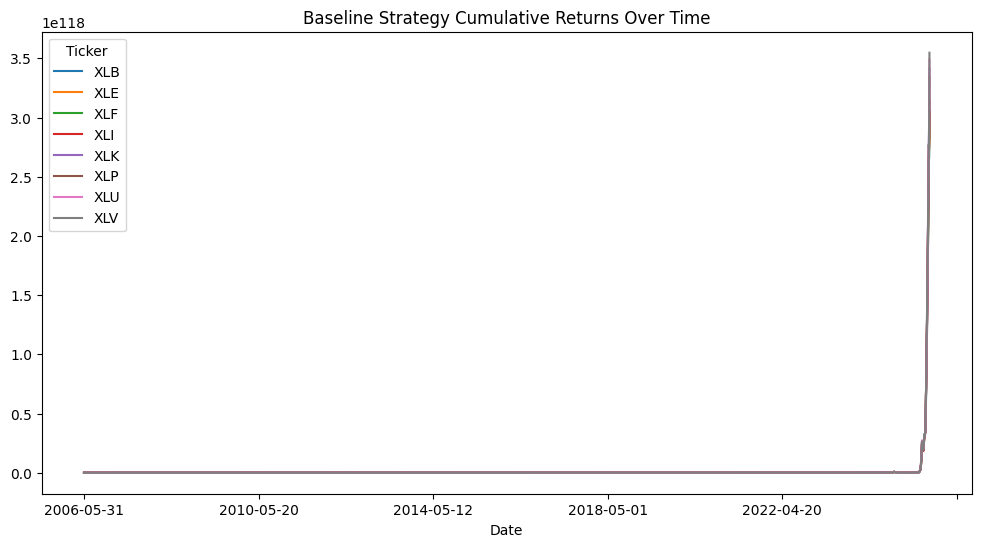

In [94]:
strategy_returns_long_only = baseline_df.groupby(["Date", "Ticker"])["passive_gross_return"].mean()

cum_strategy_returns_long_only = strategy_returns_long_only.cumprod()
cum_strategy_returns_long_only.unstack().plot(figsize=(12,6), title='Baseline Strategy Cumulative Returns Over Time')

# Learning to rank

LTR is a supervised step that replaces or refines the combination step. It involves training a model that ranks stocks by expected future return. Instead of predicting exact returns, it learns an ordering of stocks that maximizes predictive power. LTR can capture non-linear interactions between factors that IC weighting or simple averaging cannot. It’s particularly useful when you have many factors or some factors are highly correlated.

Inputs: 
- Neutralised factor columns (or other features) per stock per date
- Forward returns (target variable)

Outputs:
- A predicted ranking score for each stock per date, essentially a refined composite alpha column like in the traditional pipeline

How it differs from the traditional pipeline

| Step                 | Approach                                                   | Output                                  |
| -------------------- | ---------------------------------------------------------- | --------------------------------------- |
| Equal / IC weighting | Linear combination of factors                              | Composite alpha                         |
| Learning to Rank     | Model (e.g., XGBoost, LightGBM) trained to predict ranking | Refined composite alpha / ranking score
 |


In [95]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [96]:
xg_df = baseline_df.drop(columns=['composite_alpha', 'rank', 'pct_rank', 'signal', 'strategy_return']).copy()
factor_cols = [c for c in xg_df.columns if c.startswith("alpha")]
X = xg_df[factor_cols]
y = xg_df["forward_return"]

<Axes: title={'center': 'XGBoost Strategy Daily Returns Over Time'}, xlabel='Date,Ticker'>

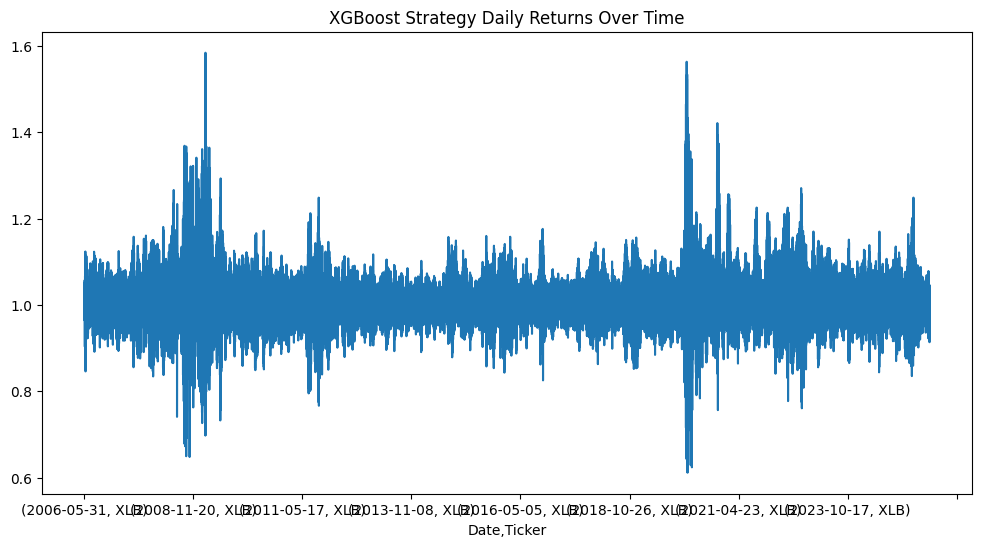

In [97]:
# time-aware split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.2)

# model
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# predict forward returns
xg_df["pred"] = model.predict(X)

# rank predictions per date → long/short
xg_df["rank"] = xg_df.groupby("Date")["pred"].rank(pct=True)
xg_df["signal"] = (xg_df["rank"] > 0.5).astype(int) * 2 - 1

xg_df['strategy_return'] = xg_df['signal'] * xg_df['forward_return']

xg_df['gross_return'] = xg_df['strategy_return'] + 1
strategy_returns = xg_df.groupby(["Date", "Ticker"])["gross_return"].mean()
display(strategy_returns.plot(figsize=(12,6), title='XGBoost Strategy Daily Returns Over Time'))
cum_strategy_returns = strategy_returns.cumprod()

In [98]:
strategy_returns.mean()

1.0071506017592233

In [99]:
cum_strategy_returns_long_only.describe()

count     3.875200e+04
mean     9.497241e+115
std      1.322239e+117
min       2.653020e-30
25%       8.272463e+13
50%       8.201253e+46
75%       1.565885e+77
max      3.547518e+118
Name: passive_gross_return, dtype: float64

In [110]:
cum_strategy_returns.describe()

count     3.875200e+04
mean     1.160800e+130
std      1.194390e+131
min       9.402675e-01
25%       2.578646e+32
50%       1.072886e+56
75%       4.250169e+89
max      2.021204e+132
Name: gross_return, dtype: float64

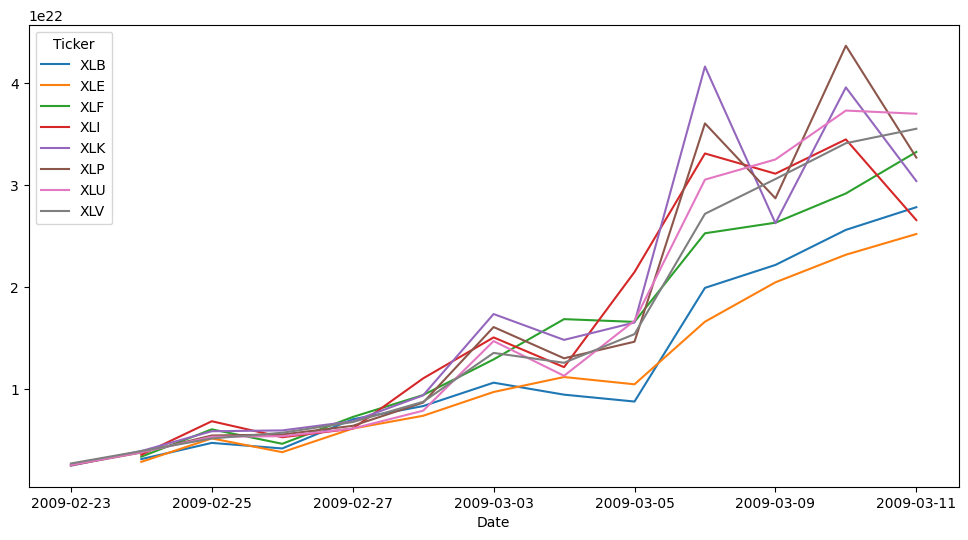

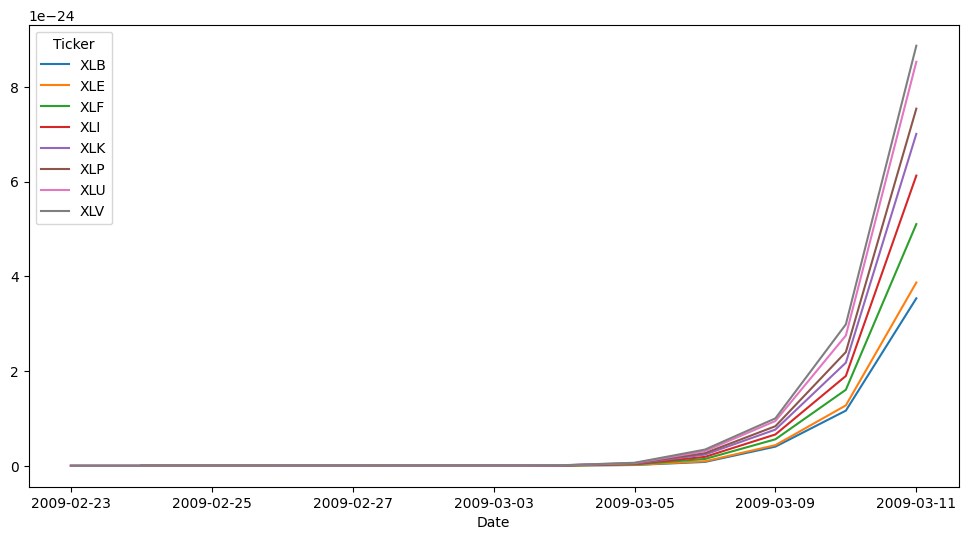

In [119]:
start, end = 5500, 5600

cum_strategy_returns.iloc[start:end].unstack().plot(figsize=(12,6), label='XGBoost Strategy Cumulative Returns Over Time', legend=True);
cum_strategy_returns_long_only.iloc[start:end].unstack().plot(figsize=(12,6), label='Baseline long only Cumulative Returns Over Time', legend=True);

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15810
[LightGBM] [Info] Number of data points in the train set: 31001, number of used features: 62
[LightGBM] [Info] Start training from score 0.008832


<Axes: title={'center': 'XGBoost Strategy Daily Returns Over Time'}, xlabel='Date,Ticker'>

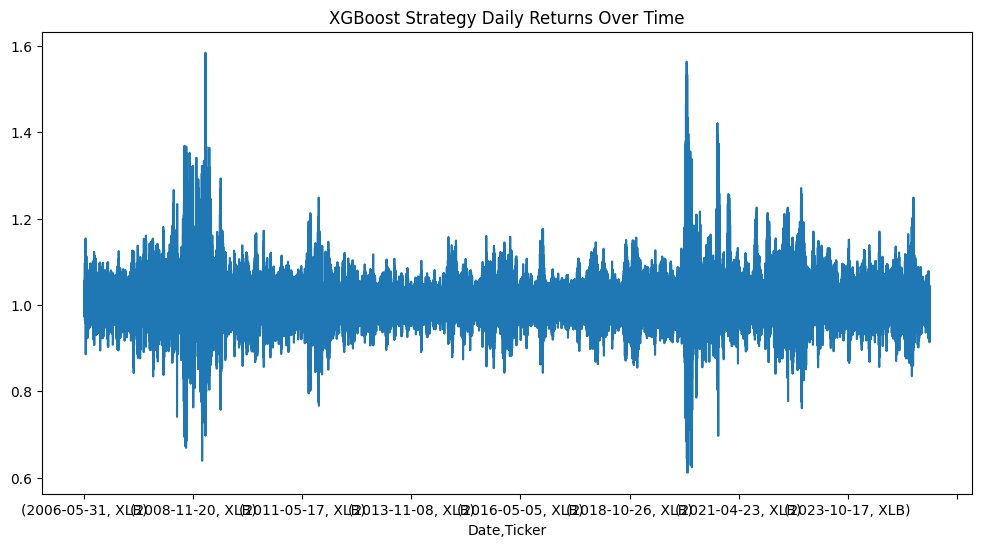

In [101]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

lgb_df = baseline_df.drop(columns=['composite_alpha', 'rank', 'pct_rank', 'signal', 'strategy_return']).copy()

model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)

lgb_df["pred"] = model.predict(X)

# rank predictions per date → long/short
lgb_df["rank"] = lgb_df.groupby("Date")["pred"].rank(pct=True)
lgb_df["signal"] = (lgb_df["rank"] > 0.5).astype(int) * 2 - 1

lgb_df['strategy_return'] = lgb_df['signal'] * lgb_df['forward_return']

lgb_df['gross_return'] = lgb_df['strategy_return'] + 1
strategy_returns = lgb_df.groupby(["Date", "Ticker"])["gross_return"].mean()
display(strategy_returns.plot(figsize=(12,6), title='XGBoost Strategy Daily Returns Over Time'))
cum_strategy_returns = strategy_returns.cumprod()

<Axes: xlabel='Date'>

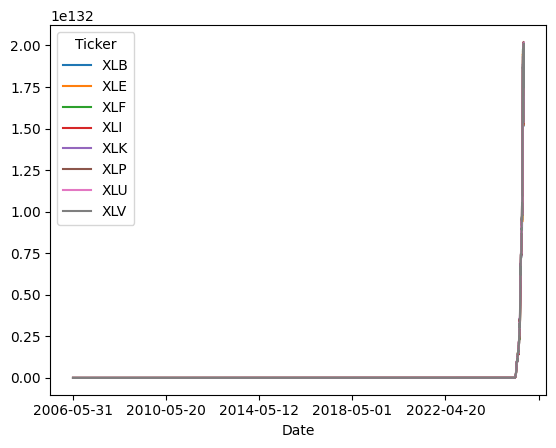

In [102]:
cum_strategy_returns.unstack().plot()

<Axes: title={'center': 'LightGBM Strategy Cumulative Returns Over Time'}, xlabel='Date'>

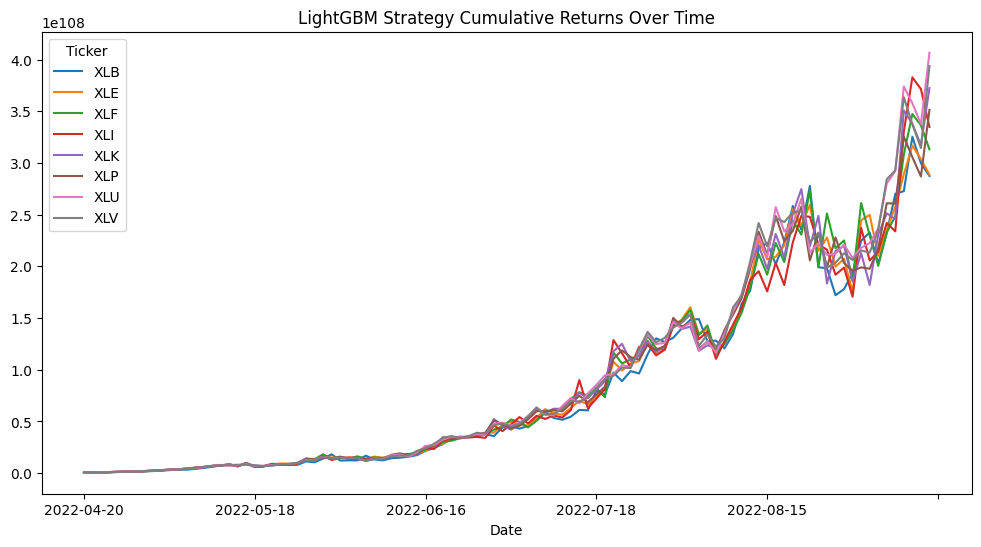

In [103]:
cum_strategy_returns.unstack().iloc[4000:4100].plot(figsize=(12,6), title='LightGBM Strategy Cumulative Returns Over Time')
# cum_strategy_returns.plot(figsize=(12,6), title='LightGBM Strategy Cumulative Returns Over Time')

In [104]:
cum_strategy_returns, cum_strategy_returns_long_only

(Date        Ticker
 2006-05-31  XLB        9.896899e-01
             XLE        1.008689e+00
             XLF        1.022133e+00
             XLI        1.010699e+00
             XLK        1.027236e+00
                           ...      
 2025-08-29  XLI       1.823952e+132
             XLK       1.666534e+132
             XLP       1.702535e+132
             XLU       1.778648e+132
             XLV       1.749601e+132
 Name: gross_return, Length: 38752, dtype: float64,
 Date        Ticker
 2006-05-31  XLB        9.896899e-01
             XLE        1.008689e+00
             XLF        9.952455e-01
             XLI        9.841122e-01
             XLK        9.680098e-01
                           ...      
 2025-08-29  XLI       3.143607e+118
             XLK       3.414918e+118
             XLP       3.341148e+118
             XLU       3.490515e+118
             XLV       3.547518e+118
 Name: passive_gross_return, Length: 38752, dtype: float64)

In [105]:
lgb_df[['Ticker','signal']].value_counts().sort_index()

Ticker  signal
XLB     -1        2619
         1        2225
XLE     -1        2820
         1        2024
XLF     -1        2247
         1        2597
XLI     -1        2303
         1        2541
XLK     -1        1907
         1        2937
XLP     -1        2646
         1        2198
XLU     -1        2620
         1        2224
XLV     -1        2214
         1        2630
Name: count, dtype: int64

The implementation of RankNet, ListNet, and ListMLE differ in how the input data is constructed and in the loss functions used, the way the model handles input data, and how it processes the output.

**LTR Network**

- Two hidden layers (width tunable), dropout, ReLU activations
- Acts as a score generator: it takes features (neutralised factors) as input and outputs a scalar score per stock
- This stays the same regardless of which LTR method is used

**RankNet, ListNet, ListMLE**

Input processing

| Method                 | Input format                                   | Description                                                                                                                                                   |
| ---------------------- | ---------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **RankNet (pairwise)** | Pairs of stocks `(i, j)` for the same date     | Predicts probability that `i` beats `j` in forward return. Loss compares predicted pairwise order vs actual order.                                             |
| **ListNet (listwise)** | Entire cross-section (list of stocks per date) | Computes a probability distribution over the list (softmax over predicted scores and targets). Loss is cross-entropy between predicted and true distributions. |
| **ListMLE (listwise)** | Entire cross-section (list of stocks per date) | Uses the likelihood of the observed ranking; sorts targets descending, computes log-likelihood of predicted ordering.                                         Loss function
 |


| Method      | Type     | Description                                                                                               |
| ----------- | -------- | --------------------------------------------------------------------------------------------------------- |
| **RankNet** | Pairwise | Compares all pairs of stocks. Encourages the network to give higher scores to stocks with higher returns. |
| **ListNet** | Listwise | Considers the entire list of stocks simultaneously, modeling probability distributions over rankings.     |
| **ListMLE** | Listwise | Maximizes the likelihood of the observed ranking over the list.                                           |


RankNet Implementation